# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 13 - Change Point Detection

Change point detection (CPD) is the problem of finding abrupt changes in data when a property of the time series changes. This can happen so frequently in the real world. Detecting the moments when loss of concentration, change in driving conditions, change in weather, and drop in stocks can be examples.

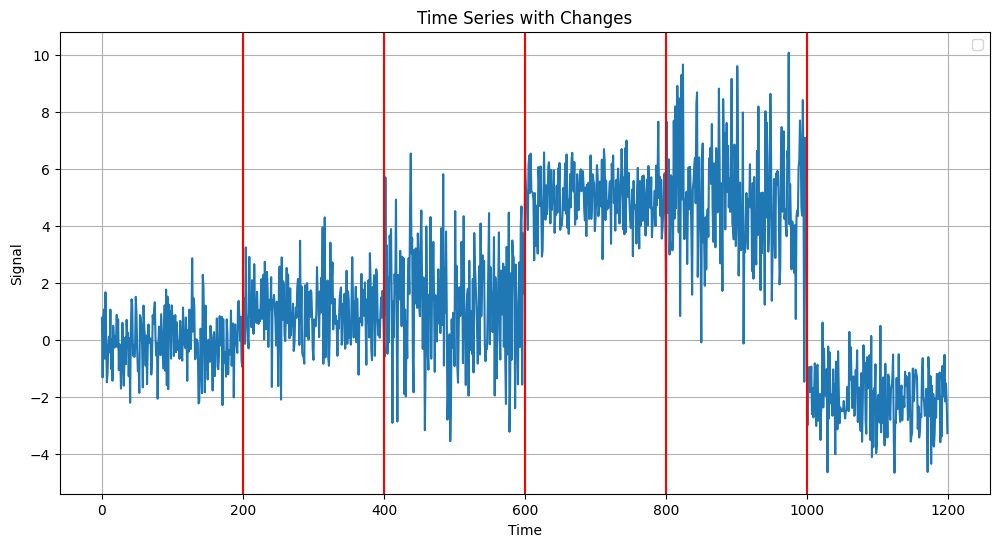

Change point detection is a powerful technique that helps you identify significant changes in your time series data, which can provide valuable insights for decision making and forecasting.

However, detecting change points can be challenging, especially when working with noisy or complex data.

## Change Detection in Time Series

Time series change point detection is a technique used to identify points in a time series data set where the statistical properties of the data change. These changes can be due to a variety of factors, such as changes in trends, seasonality, or the underlying process that generated the data. Identifying change points is important because it can help investors understand how data is evolving over time and make more informed and accurate predictions about future performance.

## Changepoint detection categories

There are two different categories of CPD: offline and online.

### Offline Change Point Detection

Change point detection approaches are “offline” when they do not use live streaming data and require the full time series for statistical analysis. Since offline approaches analyze the entire time series, they are generally more accurate. Some characteristics of offline change point detection are as follows:

- All data is received and processed at the same time
- All changes are of interest, not just the most recent change in the sequence

### Online Change Point Detection

In contrast to offline change point detection, online change point detection is used on live streaming time series, typically for ongoing monitoring or immediate anomaly detection. Online CPD processes individual data points as they become available, with the intention of detecting state changes as soon as they occur. Some characteristics of online change point detection include:

- Fast “on-the-fly” processing, to quickly assess changes in the trend of the time series
- Assessment of only the most recent change in the time series, not previous changes

## Change Point Detection Algorithms

There are some interesting methods that can help to get better insights by adding some parameters to select the number of change points the user wants to detect.

## Use case: Deforestation detection with CPD algorithms

Let's connect to Drive and access our file to perform the example:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import geopandas as gpd
from shapely import box

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

Link to the dataset: https://drive.google.com/drive/folders/1xX6gn0JfJMj71zg4qPoRGxNuLO6yVxAb?usp=sharing

In [ ]:
path_gpd = '/content/drive/MyDrive/Datasets_TS/deforestation/dashboard_alerts-shapefile.shp'

Now we can open the .shp with geopandas and get the boundbox:

In [ ]:
gpd_area = gpd.read_file(path_gpd)

<Axes: >

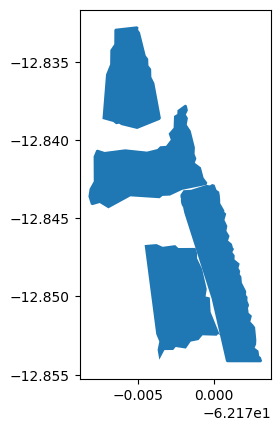

In [ ]:
gpd_area.plot()

In [ ]:
gdf_bounds = gpd.GeoDataFrame(geometry=[box(*gpd_area.geometry.unary_union.bounds)], crs = gpd_area.crs)

<ipython-input-7-d954a2b0c880>:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_bounds = gpd.GeoDataFrame(geometry=[box(*gpd_area.geometry.unary_union.bounds)], crs = gpd_area.crs)


We convert the boundbox into a Feature Collection:

In [ ]:
fc = geemap.geopandas_to_ee(gdf_bounds)

Let's get two images, one from 2018 and one from 2024 to compare the before and after:

In [ ]:
s2_sr_cld_col_2018 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterBounds(fc).filterDate('2018-01-01', '2018-12-31').filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',20))
s2_sr_cld_col_2024 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterBounds(fc).filterDate('2024-01-01', '2024-12-31').filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',20))

In [ ]:
s2_img_2018 = s2_sr_cld_col_2018.median().clip(fc)
s2_img_2024 = s2_sr_cld_col_2024.median().clip(fc)

We can visualize the images in a splitMap:

In [ ]:
vis_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}

Map = geemap.Map()

Map.centerObject(fc, 15)  # Center the map on the area of interest

left_layer = geemap.ee_tile_layer(s2_img_2018, vis_params, "Sentinel-2 2018")
right_layer = geemap.ee_tile_layer(s2_img_2024, vis_params, "Sentinel-2 2024")


Map.split_map(left_layer, right_layer)
Map.add_basemap("HYBRID")
Map.addLayerControl()
Map.addLayer(fc, {}, "Area")
Map


In [ ]:
fc = geemap.geopandas_to_ee(gpd_area)

Now let's get a series of images from 2018 to 2020:

In [ ]:
s2_sr_cld_col= ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterBounds(fc).filterDate('2018-01-01', '2020-12-31').filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',20))

Let's add NDVI to the time series:

In [ ]:
def addNDVI(image):
  ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
  return image.addBands(ndvi)

s2_sr_cld_col = s2_sr_cld_col.map(addNDVI)

Then we extract a time series of the average NDVI of our analysis area:

In [ ]:
def extract_ndvi_timeseries(image):
  mean_ndvi = image.select('NDVI').reduceRegion(
      reducer=ee.Reducer.mean(),
      geometry=fc.geometry(),
      scale=10
  ).get('NDVI')
  return image.set('date', image.date().format()).set('mean_ndvi', mean_ndvi)

ndvi_timeseries = s2_sr_cld_col.map(extract_ndvi_timeseries)

Converting to a DataFrame:

In [ ]:
data = ndvi_timeseries.toList(s2_sr_cld_col.size()).getInfo()
df = pd.DataFrame(data)

In [ ]:
df['date'] = [item.get('date', None) for item in df['properties']]
df['mean_ndvi'] = [item.get('mean_ndvi', None) for item in df['properties']]


df = df.dropna(subset=['date', 'mean_ndvi'])
df['date'] = pd.to_datetime(df['date'])
df['mean_ndvi'] = pd.to_numeric(df['mean_ndvi'])
df = df.set_index('date')

df = df.drop(columns=['type','bands','version','id','properties'])
df

,mean_ndvi
date,
2018-06-22 14:26:24,0.879116
2019-03-19 14:26:24,0.808137
2019-04-08 14:26:29,0.761100
2019-04-18 14:26:31,0.834269
2019-04-26 14:36:24,0.866298
...,...
2020-11-03 14:26:30,0.393368
2020-11-06 14:36:25,0.431364
2020-11-21 14:36:21,0.436442


<Axes: xlabel='date'>

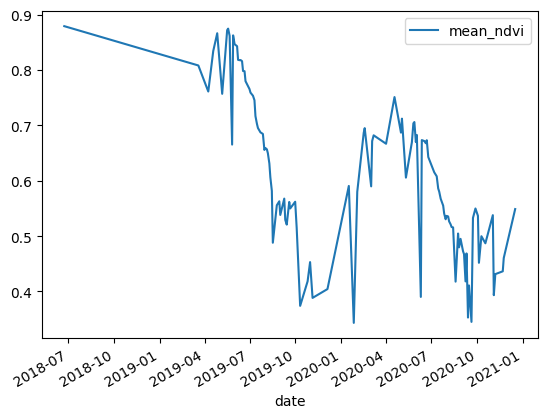

In [ ]:
df.plot()

Let's smooth the series by applying the moving average:

<Axes: xlabel='date'>

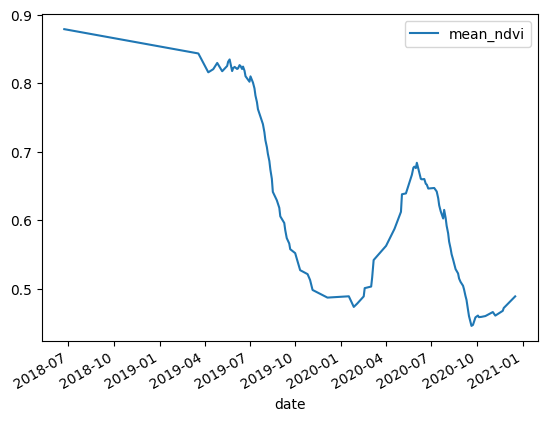

In [ ]:
df_new = df.rolling(window=12, min_periods=1).mean()
df_new.plot()

### Binary Segmentation

Binary change point detection is used to perform fast signal segmentation. The process of this binary segmentation is as follows. First, using all the data, it detects a change point. Then the data is divided into two around this change point. Then the division process is repeated for each two subdata. If the calculated change point is greater than some criteria, it is accepted to change point.

Binary segmentation is quite simple: first, it looks for a single change point in the entire signal.

Once it finds that point, it splits the signal into two parts and repeats the process for each of those parts.

This continues until no more change points are found or a specified stopping criterion is met.


It has low complexity, meaning it doesn’t take much time or computing power to run and is a good choice for large data sets.

A downside is that it can sometimes miss change points or detect false points, especially when the changes are close together or the signal is noisy.

In addition, it is a greedy algorithm, meaning it makes decisions based on the immediate best choice without considering the overall impact on the final result.

This can lead to suboptimal solutions in some cases

In [ ]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.7 MB/s eta 0:00:00


In [ ]:
import ruptures as rpt

Let's use Binseg:

In [ ]:
algo = rpt.Binseg(model="l2", min_size=28)
algo.fit(df_new)
result = algo.predict(1)

In [ ]:
result

[35, 113]

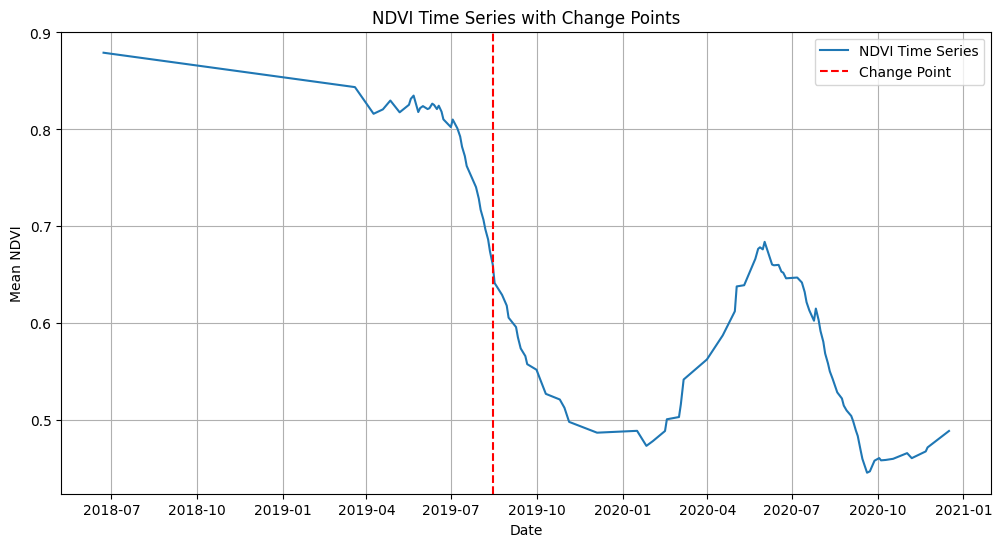

In [ ]:
import matplotlib.pyplot as plt

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_new.index, df_new['mean_ndvi'], label='NDVI Time Series')


# Highlight change points
for cp in result[:-1]:
    plt.axvline(x=df_new.index[cp], color='red', linestyle='--', label='Change Point' if cp == result[0] else '')

plt.xlabel('Date')
plt.ylabel('Mean NDVI')
plt.title('NDVI Time Series with Change Points')
plt.legend()
plt.grid(True)
plt.show()

### PELT

The PELT method considers the data sequentially and searches the solution space exhaustively. Computational efficiency is achieved by removing solution paths that are known not to lead to optimization. The main assumption of the PELT algorithm is that the number of change points increases linearly with increasing data set, i.e., the change points are spread throughout the data and are not restricted to a single part of the data.

The PELT method is more efficient and more accurate than Binary Segmentation for our choice of penalty. PELT produces faster and more consistent results than either eye-identification or assuming constant variability.

Some important insights about change point detection are:

- There is no one method that can solve all the problems in detecting change points.
- To detect the main change point in the time series, several methods can be applied.
- But to detect the multiple change points existing in a dataset, the PELT algorithm performs best.

PELT (Pruned Exact Linear Time) has a lot of cool advantages.

One of the main benefits is that it is super fast when certain conditions are met, which makes it a great choice for large data sets.

Another advantage is that PELT can handle a variety of penalty functions, even concave curves!

So it is quite versatile and can be used in a variety of situations.

However, there are a few things to keep in mind.

In some cases, when pruning doesn’t happen, PELT can get a bit slow and end up with a computational cost that grows as the square of the number of data points. So it’s not always perfect.

Also, when it comes to these concave curved penalty functions, the simple approach that PELT uses to update the penalty constant may not always find the best number of change points.

Sometimes it can work well, but in other cases, you may need to use a more sophisticated search method to ensure that you get the most accurate results.

In [ ]:
algo = rpt.Pelt(model="l2", min_size=28)
algo.fit(df_new)
result = algo.predict(pen=1)

If there is more than one resulting value, we can present it alongside the time series to see where the change point is:

In [ ]:
if len(result) > 1:
  print("Changepoint detected")
  print(result[:-1])
else:
  print("No changepoint detected")

Changepoint detected
[35]


In [ ]:
df_new[df_new.index.isin(df_new.index[result[:-1]])].index

DatetimeIndex(['2019-08-14 14:36:24'], dtype='datetime64[ns]', name='date', freq=None)

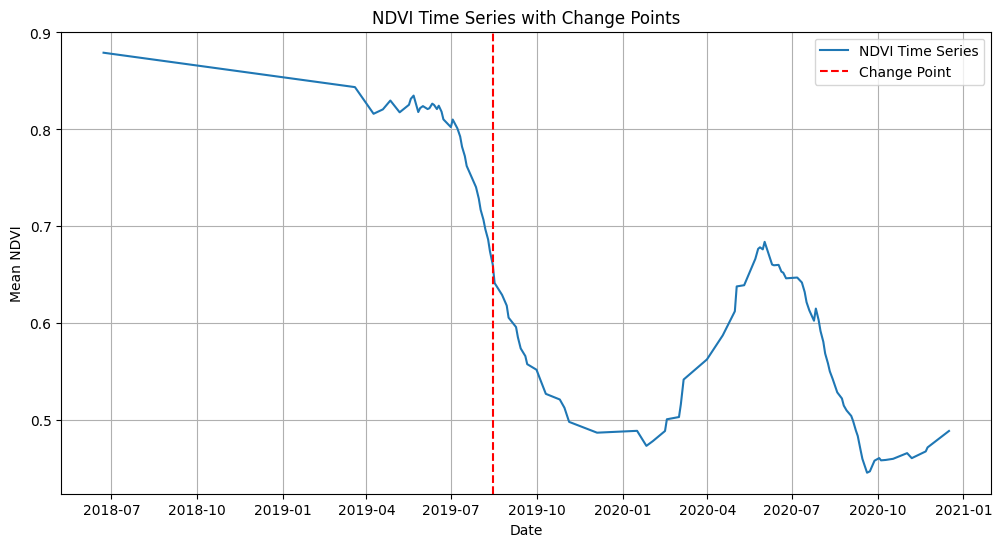

In [ ]:
import matplotlib.pyplot as plt

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_new.index, df_new['mean_ndvi'], label='NDVI Time Series')


# Highlight change points
for cp in result[:-1]:
    plt.axvline(x=df_new.index[cp], color='red', linestyle='--', label='Change Point' if cp == result[0] else '')

plt.xlabel('Date')
plt.ylabel('Mean NDVI')
plt.title('NDVI Time Series with Change Points')
plt.legend()
plt.grid(True)
plt.show()


### Random Forest Change Point Detection

Changepoint detection aims to identify structural breaks in the probability distribution of a time series. Existing methods either assume a parametric model for within-segment distributions or are based on ranks or distances, and therefore fail in scenarios with reasonably high dimensionality.

Changeforest implements a classifier-based algorithm that consistently estimates changepoints without any parametric assumptions, even in high-dimensional scenarios. It uses the out-of-bag probability predictions from a random forest to construct a classifier log-likelihood ratio that is optimized using a computationally feasible two-step method.

Random Forest Change Point Detection or rfpop is a method for detecting change points in time series data using random forests. It is a nonparametric approach that does not assume a specific functional form for the time series data. The rfpop method works by fitting a random forest model to the time series data and using the model to identify points in the data where there are significant changes in the underlying trend or pattern. To do this, the method compares the predicted values ​​from the random forest model to the observed values ​​in the time series data and looks for significant deviations between the two. If a significant deviation is found, it is treated as a potential change point.

In [ ]:
!pip install changeforest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.0 MB/s eta 0:00:00


In [ ]:
from changeforest import changeforest
from changeforest import Control

Let's apply changeforest:

In [ ]:
result = changeforest(df_new.values, "random_forest", "bs", Control(random_forest_n_estimators=100))
result

                      best_split max_gain p_value
(0, 113]                      29   64.844   0.005
 ¦--(0, 29]                   22   14.612   0.005
 ¦   ¦--(0, 22]               19    8.569    0.03
 ¦   °--(22, 29]              26    4.419    0.04
 °--(29, 113]                 98   26.403   0.005
     ¦--(29, 98]              33   15.923   0.005
     ¦   ¦--(29, 33]                             
     ¦   °--(33, 98]          35   -4.988     0.9
     °--(98, 113]            110    0.417   0.595

In [ ]:
result.split_points()

[22, 29, 33, 98]

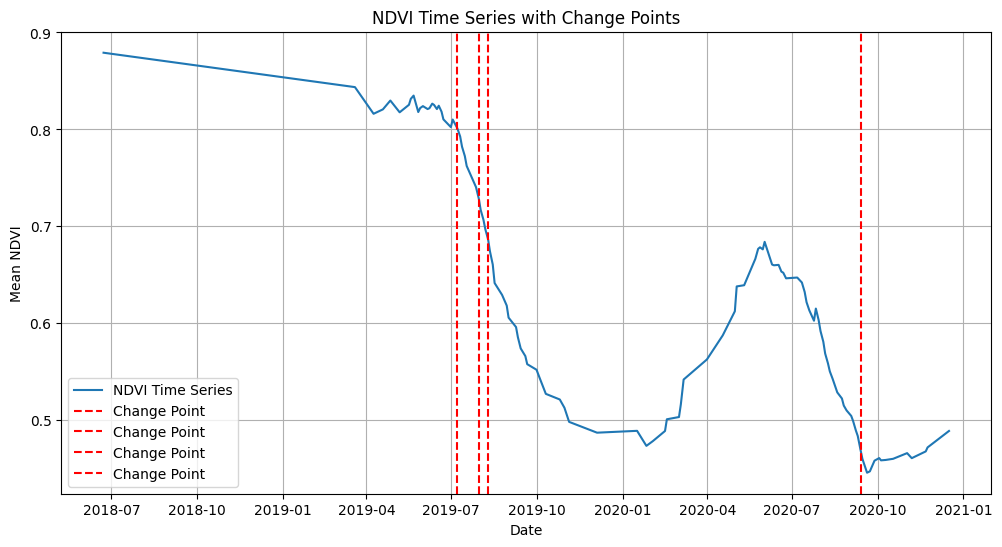

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_new.index, df_new['mean_ndvi'], label='NDVI Time Series')


# Highlight change points
for cp in result.split_points():
    plt.axvline(x=df_new.index[cp], color='red', linestyle='--', label='Change Point')

plt.xlabel('Date')
plt.ylabel('Mean NDVI')
plt.title('NDVI Time Series with Change Points')
plt.legend()
plt.grid(True)
plt.show()

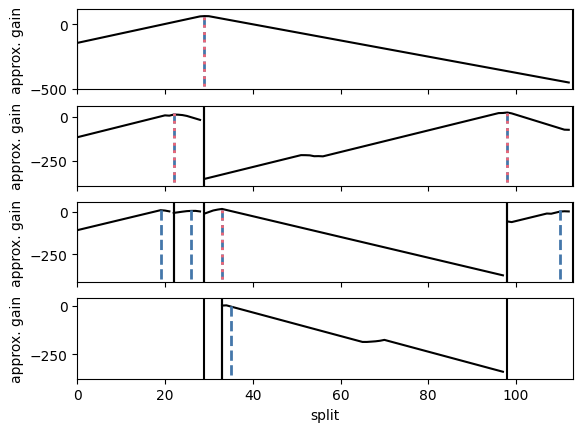

In [ ]:
result.plot().show()

## Thank you! See you in the next Chapter!

References:

https://medium.datadriveninvestor.com/maximize-your-time-series-analysis-with-pythons-change-point-detection-tools-39ce2bc63be

https://www.kaggle.com/code/yejining99/change-point-detection

https://forecastegy.com/posts/change-point-detection-time-series-python/#:~:text=Ruptures%20is%20a%20Python%20library,%2C%20and%20Window%2Dbased%20methods.

https://medium.com/@chamanthiaki5/introduction-to-change-point-detection-d6a04da25a83